Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as any collaborators you worked with:

In [1]:
COLLABORATORS = ""

## To receive credit for this assignment, you must also fill out the [AI Use survey](https://forms.gle/ZhR5k8TdAeN8rj4CA)


---

In [2]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

Before you turn this problem in, make sure everything runs as expected. First, restart the kernel (in the menubar, select Kernel $\rightarrow$ Restart) and then run all cells (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says YOUR CODE HERE or "YOUR ANSWER HERE", as well as your name and collaborators below:

# HW 3:  Interpolation and applications

## Question 1

Consider data at three points $(x_0, y_0) = (0, 0)$, $(x_1, y_1) = (1, 2)$, and $(x_2, y_2) = (2, 2)$.

**(a)** [ 8 pts] Analytically find coefficients of the interpolating  polynomial $P_2(x)$ that passes through these three points in the following bases
1. Monomial: $P(x) = p_0 + p_1 x + p_2 x^2$
1. Lagrange: $P(x) = \sum^2_{k=0} y_k \ell_k(x)$


and show that the two polynomials are identical.



MONOMIAL BASIS

Begin with three equations generated from the monomial general form and pluggging in each point:
$$
p_0 = 0 \\
p_0 + p_1 + p_2 = 2 \\
p_0 + 2 p_1 + 4 p_2 = 2 \\
$$

Transform this system into a matrix equation that we can solve:
$$
\begin{bmatrix} 
     1 & 0 & 0 \\
     1 & 1 & 1 \\
     1 & 2 & 4
\end{bmatrix} 
\begin{bmatrix} p_0 \\ p_1 \\ p_2 \end{bmatrix} = 
\begin{bmatrix} 0 \\ 2 \\ 2 \end{bmatrix} \\

A \mathbf{p} = \mathbf{b}
$$

Row reduce to solve:
$$
A = 
\begin{bmatrix} 
     1 & 0 & 0 \\
     0 & 1 & 0 \\
     0 & 0 & 1
\end{bmatrix} 
\\ 
\textbf{p} = 
\begin{bmatrix}
     0 \\
     3 \\
     -1
\end{bmatrix}
$$

Thus, $P(x)$ is:
$$
P(x) = 3x - (x^2)
$$


LAGRANGE BASIS
We have N+1 = 3 points.
$$
N = 2 \\
l_0(x) = \frac{x - 1}{0 - 1} \frac{x - 2}{0 - 2} = 0.5(1-x)(2-x) \\
l_1(x) = \frac{x - 0}{1 - 0} \frac{x - 2}{1 - 2} = x(2-x) \\
l_2(x) = \frac{x - 0}{2 - 0} \frac{x - 1}{2 - 1} = 0.5x(x-1) \\
$$

Knowing $l_i(x_j) = \delta_{ij}$, writing the $A \mathbf{y} = \mathbf{b}$ is trivial:
$$
\begin{bmatrix} 
     1 & 0 & 0 \\
     0 & 1 & 0 \\
     0 & 0 & 1
\end{bmatrix} 
\begin{bmatrix} y_0 \\ y_1 \\ y_2 \end{bmatrix} = 
\begin{bmatrix} 0 \\ 2 \\ 2 \end{bmatrix} \\

P(x) = 2 l_1(x) + 2 l_2(x)

$$

Notice because of the Dirac delta nature of the Lagrange basis, the polynomial coefficients are simply the $y$ values of the points we are interpolating to.

Plugging in what we got for the Lagrange basis functions, we can simplify and see that this polynomial is identical to the one we got when using the monomial basis:
$$
P(x) = 3x-x^2
$$

**(b)** [4 pts] Any $N+1$ distinct values of $x$ uniquely define the $N+1$ Lagrange polynomials $\ell_0(x), \ell_1(x)\ldots\ell_N(x)$

show that these functions satisfy 

$$\sum^N_{i=0} \ell_i(x) = 1$$

for all values of $x$ (not just the nodes).  We say that the Lagrange polynomials form a "Partition of Unity" because they always sum to 1.

Hint:  consider interpolation of a constant function, $f(x) = c$ sampled at $N+1$ distinct points.


Let's use the Lagrange basis to interpolate $f(x) = c$, $c = $ a constant, sampled at $N+1$ distinct points:

$$
f(x) = c = \sum_{i=0}^N \left( \prod_{j=0,j\neq i}^N \left( y_i \frac{x-x_j}{x_i-x_j} \right) \right)
$$

Do some math:

$$
1 = \frac{1}{c} \sum_{i=0}^N \left( \prod_{j=0,j\neq i}^N \left( y_i \frac{x-x_j}{x_i-x_j} \right) \right) \\
1 = \sum_{i=0}^N \left( \prod_{j=0,j\neq i}^N \left( \frac{y_i}{c} \frac{x-x_j}{x_i-x_j} \right) \right)
$$

But $y_i$ is always $= c$ in this case, since any $x_i$ will give $f(x_i)=c$ as we defined earlier. So, $y_i/c=1$ for all $i$. Thus:

$$
1 = \sum_{i=0}^N \left( \prod_{j=0,j\neq i}^N \left( \frac{x-x_j}{x_i-x_j} \right) \right) \\
1 = \sum_{i=0}^N \left( l_i(x) \right)

## Question 2: Fun with Chebyshev Polynomials

**(a)** [4 pts] The $n$th Chebyshev polynomial is characterized (up to a constant) by the identity

$$T_n(\cos \theta) = \cos (n \theta)$$

Use this identity to show that the Chebyshev polynomials are orthogonal on $x\in[-1,1]$ with respect to the weight

$$\omega(x) = \frac{1}{\sqrt{1 - x^2}}$$

To do this you must prove that

$$\int^1_{-1} \omega(x) T_n(x) T_m(x) dx = \left \{ \begin{aligned} 
a & ~ & m = n \\ 
0 & ~ & m \neq n 
\end{aligned} \right .$$

where $a$ is a finite constant (also find this coefficient).  Note that you may have multiple non-zero coefficients $a$.  Make sure to cover all these cases and list the conditions that you will find these values.

$$

\int^1_{-1} \frac{1}{\sqrt{1-x^2}} T_n(x) T_m(x) dx = \left \{ \begin{aligned} 
a & ~ & m = n \\ 
0 & ~ & m \neq n 
\end{aligned} \right . \\

$$ 

Change variables: 
$$
x \equiv cos(\theta), dx = -sin(\theta) d\theta \\

\int^0_{\pi} \frac{-1}{\sqrt{1-cos^2(\theta)}} T_n(cos(\theta)) T_m(cos(\theta)) sin(\theta) d\theta = \left \{ \begin{aligned} 
a & ~ & m = n \\ 
0 & ~ & m \neq n 
\end{aligned} \right .
$$

Use the identity $1 = sin^2(\theta) + cos^2(\theta)$ and $T_n(\cos \theta) = \cos (n \theta)$ to rewrite this integral and cancel out relevant terms:

$$
\int^\pi_{0} cos(n\theta) cos(m\theta) d\theta = \left \{ \begin{aligned} a & ~ & m = n \\ 
0 & ~ & m \neq n 
\end{aligned} \right .
$$

Solving this integral (not showing explicit steps but can be done relatively easily using trigonometric identities):

$$
\left \{ \begin{aligned} 
\pi & ~ & m = n = 0 \\ 
\frac{\pi}{2} & ~ & m = n \neq 0 \\
0 & ~ & m \neq n \\

\end{aligned} \right . = \left \{ \begin{aligned} a & ~ & m = n \\ 
0 & ~ & m \neq n 
\end{aligned} \right .
$$

So $a$ takes on different values depending on the values of $m$ and $n$.

**(b)** [4 pts] Consider the  Gaussian 
$ f(x) = e^{-(x-3)^2} $ on the interval $x\in[0,6]$

make a plot comparing the polynomial interpolant through $N=11$ points using 
* Evenly spaced points
* The appropriate Chebyshev nodes (i.e. roots of $T_{11}$: **note** you will need to transform the nodes defined on the interval $s\in[-1,1]$ to $x\in[0,6]$)

Be sure to show both the interpolation points and a reasonably resolved interpolating polynomial $P_{10}(x)$, and label all lines and axes.

You can use any of the routines from the notes or `numpy.polyfit` and `numpy.polyval`.  
For fun, experiment with other functions (e.g. Runge's function $f(x) = 1/(1 + 25x^2)$)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
f = lambda x: np.exp(-1* ((x-3)**2))
def ch_roots(N): # N=degree
    # N=N+1
    k = np.linspace(1,N,N)
    return np.cos((2*k-1)*np.pi / (2*(N)))

N=11 # number of data points
x_even = np.linspace(0,6,11)
x_ch = ch_roots(N)
x_ch_at = ((0+6)/2) + x_ch * ((6 - 0)/2) # transform roots to x=[0,6] from x=[-1,1]


p_even = np.polyfit(x_even,f(x_even),N-1) # polynomial degree N can be used to interpolate N+1 data points
p_ch = np.polyfit(x_ch_at,f(x_ch_at),N-1)

x_plt = np.linspace(0,6,50)
plt.figure(1)
plt.plot(x_plt,np.polyval(p_even,x_plt),label="Evenly Spaced")
plt.plot(x_plt,np.polyval(p_ch,x_plt),label="Chebyshev nodes")
# plt.plot(x_plt,np.exp(-1* ((x_plt-3)**2)))
plt.xlabel("x")
plt.ylabel("f")
plt.title("Comparing Chebyshev Nodes With Evenly Spaced Nodes for a Gaussian Function")
plt.legend()

**(c)** [4 pts] define the relative error as
        
$$
 r = \frac{||f(x) - P_N(x)||}{||f(x)||}
$$

where $||\cdot||$ is an appropriate norm (length) of a vector, in python you can calculate this by

```python
x = numpy.linspace(x_min, x_max)
P_N = numpy.polyval(p, x)

err = f(x) - P_N(x)
r = numpy.linalg.norm(err)/numpy.linalg.norm(f(x))
```

* Make a well labeled plot showing log(r) vs number of grid points $N$ for $N\in[5,30]$ 
* Comment briefly on your results. Some questions to consider are:
    *  does $P_N(x)\rightarrow f(x)$ as $N\rightarrow\infty$?
    *  Is one interpolant more accurate than the other?
    * Anything else you notice

/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_1568/3752305963.py:24: RankWarning: Polyfit may be poorly conditioned
  p_e = np.polyfit(x_even,f(x_even),N-1)
/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_1568/3752305963.py:24: RankWarning: Polyfit may be poorly conditioned
  p_e = np.polyfit(x_even,f(x_even),N-1)
/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_1568/3752305963.py:24: RankWarning: Polyfit may be poorly conditioned
  p_e = np.polyfit(x_even,f(x_even),N-1)
/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_1568/3752305963.py:24: RankWarning: Polyfit may be poorly conditioned
  p_e = np.polyfit(x_even,f(x_even),N-1)
/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_1568/3752305963.py:24: RankWarning: Polyfit may be poorly conditioned
  p_e = np.polyfit(x_even,f(x_even),N-1)
/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_1568/3752305963.py:24: RankWarning: Polyfit may be poorly conditioned
  p_e = np.polyfit(x_

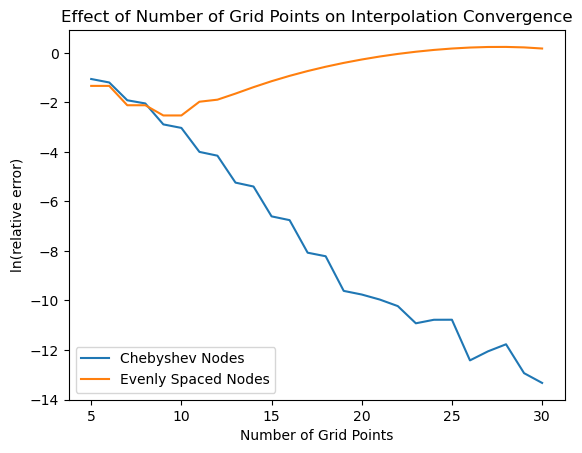

In [40]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0,6)

f = lambda y: np.exp(-1* ((y-3)**2))
def ch_roots(N): # N=degree
    # N=N+1
    k = np.linspace(1,N,N)
    return np.cos((2*k-1)*np.pi / (2*(N)))

rng = range(5,31)
r = np.zeros(len(rng))
r_e = np.zeros(len(rng))

i=0
for N in rng:
    x_ch = ch_roots(N)
    x_ch_at = ((0+6)/2) + x_ch * ((6 - 0)/2) # transform roots to x=[0,6] from x=[-1,1]
    p_ch = np.polyfit(x_ch_at,f(x_ch_at),N-1)
    err = f(x) - np.polyval(p_ch,x)
    r[i] = np.linalg.norm(err)/np.linalg.norm(f(x))
    x_even = np.linspace(0,6,11)
    p_e = np.polyfit(x_even,f(x_even),N-1)
    err_e = f(x) - np.polyval(p_e,x)
    r_e[i] = np.linalg.norm(err_e)/np.linalg.norm(f(x))
    i+=1

plt.figure(2)
plt.plot(rng,np.log(r),label='Chebyshev Nodes')
plt.plot(rng,np.log(r_e),label='Evenly Spaced Nodes')
plt.xlabel("Number of Grid Points")
plt.ylabel("ln(relative error)")
plt.title("Effect of Number of Grid Points on Interpolation Convergence")
plt.legend()

The Chebyshev nodes are definitely more accurate than the evenly spaced nodes. In fact, the evenly spaced nodes seem to not converge the interpolation. I tried to find a polynomial at around N=1000 and the polyfit function would not converge. But the Chebyshev nodes interpolation seems to converge to f(x) at these high N numbers! I checked like N=10000 quick and the Chebyshev nodes actually didnt do too well (no convergence). So idk.

## Question 3

We can often reformulate finite difference approximations as matrix-vector products.   

Here we will construct a matrix   $D$  such that multiplying a vector of $\mathbf{y}$ values would lead to a second order approximation of the First derivative for the given data. 

In other words, defining the two vectors   $\mathbf{x}=[x_0, x_1,\ldots,x_N]^T$ and $\mathbf{y}=[y_0, y_1,\ldots,y_N]^T$  such that

$$\mathbf{y} = f(\mathbf{x})$$

for some scalar function $f$,  find a matrix $D$ such that 

$$
f'(\mathbf{x}) \approx D\mathbf{y}
$$

**(a)** [16] Using any method of your choice, derive the following finite-difference formulas for 3 equispaced points $x_i, x_{i+1}, x_{i+2}$ as well as an error estimate of form $O(\Delta x^p)$

* 2nd-order accurate approximation to the *1st derivative* at  point 
    * $x_i$ (forward differences)
    * $x_{i+1}$ (centered differences)
    * $x_{i+2}$ (backward differences)
* 2nd-order accurate approximation to the *2nd derivative* evaluated at each point (hint: think before you grind)

Some hints:
1. You can either calculate the interpolating polynomial $P_2(x)$ and differentiate, or use the method of undetermined coefficients to find the finite-difference formulas.
2. However, you will need the method of undetermined coefficients to find the error estimates.



Let's redefine our index to be $n \equiv i+1$ so that the derivation in lecture applies exactly.

Note my Taylor expansions are all with respect to $x_n$, but I probably could have done this with respect to other variables like $x_{n-1}$. But we know $x_n$, so I think this is fine.

Using the method of undetermined coefficients for evenly spaced points. Every $x_{n+1}-x_n$ term or equivalently adjectent $x_i$ variations are equal to $\Delta x$. We can then use the Taylor series expansion approximation of $f(x_{n-1})$, $f(x_n)$, and $f(x_{n+1})$ as:

$$
f(x_{n+1})= f(x_n) + \Delta x f'(x_n) + \frac{\Delta x^2}{2!} f''(x_n) + \frac{\Delta x^3}{3!} f'''(x_n) + \mathcal{O}(\Delta x^4) \\

f(x_{n-1})= f(x_n) - \Delta x f'(x_n) + \frac{\Delta x^2}{2!} f''(x_n) - \frac{\Delta x^3}{3!} f'''(x_n) + \mathcal{O}(\Delta x^4) \\

f(x_i) = f(x_i)
$$

Assume the approximation for the first derivative at $x_n$ is:
$$
    f'(x_n) + R(x_n) = A f(x_{n+1}) + B f(x_n) + C f(x_{n-1})
$$

which we will try to solve for these "undetermined coefficients" $A,B,C$. Plug in the equations above for $f(x_{n+1}), f(x_n), f(x_{n-1})$ and group terms to have only one term for each $f(x_{n+1}), f(x_n), f(x_{n-1})$:

$$
f'(x_n) + R(x_n)= (A + B + C) f(x_n) + (A\Delta x +0B - C\Delta x)f'(x_n) + (A\frac{\Delta x^2}{2!} + C\frac{\Delta x^2}{2!})f''(x_n) + O(\Delta x^3)
$$

Now we match terms on the two sides of this equation. This leads to the following system of equations (note we try to set $R(x_n)=0$ to minimize error): 

$$\begin{aligned}
    f(x_n):&  &A + B + C &= 0 \\
    f'(x_n): & &A \Delta x - C \Delta x &= 1 \\
    f''(x_n): & &A \frac{\Delta x^2}{2} + C \frac{\Delta x^2}{2} &= 0
\end{aligned} $$

Rewrite as a linear system:
$$\begin{bmatrix}
1 & 1 & 1 \\
\Delta x & 0 &-\Delta x \\
\frac{\Delta x^2}{2} & 0 & \frac{\Delta x^2}{2} \\
\end{bmatrix}
\begin{bmatrix} A \\ B\\ C\\\end{bmatrix} =
\begin{bmatrix} 0 \\ 1\\ 0\\\end{bmatrix} 
$$

Which has solutions:
$$
A = \frac{1}{2 \Delta x} \\
B = 0 \\
C = \frac{-1}{2 \Delta x}
$$

So now we have:
$$
f'(x_n) =  \frac{1}{2 \Delta x} f(x_{n+1}) + \frac{-1}{2 \Delta x} f(x_{n-1}) \\
$$

And for our error, only looking at the $\mathcal{O}(\Delta x^2)$ term:
$$R(x_n) = \frac{\Delta x^2}{3!} f'''(x_n) = \mathcal{O}(\Delta x^2) \\ $$


Next, we need to find $x_{n-1}$ which is $x_i$.

$$

f'(x_{n-1})+R(x_{n-1}) = E f(x_{n-2}) + F f(x_{n-1}) + G f(x_n) \\

$$

Now use the Taylor series tp write $f(x_{n-2})$ and $f(x_{n-1})$ (only showing the former here, will use the latter in the next step):

$$

f(x_{n-2}) \approx f(x_n) - 2 \Delta x f'(x_n) + 2 (\Delta x)^2 f''(x_n) + \mathcal{0}(\Delta x^3)

$$

Now plug these into the equation above for f' and R, neglecting higher order terms than second order as is prescribed in this question:

$$
f'(x_{n-1})+R(x_{n-1}) = E \left(f(x_n) - 2 \Delta x f'(x_n) + 2 (\Delta x)^2 f''(x_n)\right) + F \left(f(x_n) - \Delta x f'(x_n) + 2 (\Delta x)^2 f''(x_n)\right) + G f(x_n) \\

f'(x_{n-1})+R(x_{n-1}) = (E+F+G) f(x_n) + (-2 \Delta x E - \Delta x F) f'(x_n) + (2 (\Delta x)^2 E + 0.5 (\Delta x)^2 F) f''(x_n)
$$

Rewrite as a linear system:
$$\begin{bmatrix}
1 & 1 & 1 \\
-2 \Delta x & -\Delta x &0 \\
2 (\Delta x)^2 & \frac{\Delta x^2}{2} & 0 \\
\end{bmatrix}
\begin{bmatrix} E \\ F\\ G\\\end{bmatrix} =
\begin{bmatrix} 0 \\ 1\\ 0\\\end{bmatrix} 
$$

$$ E = 0\\ \\
F = \frac{-1}{\Delta x}\\ \\ 
G = \frac{1}{\Delta x}\\ \\ 
$$

Thus, $f'(x_{n-1}) = \frac{-1}{\Delta x} f(x_{n-1}) + \frac{1}{\Delta x} f(x_{n})$

To find the error, we are basically saying the next order correction in our Taylor series is the error, so calculate the third term in the Taylor series (on the $f'''(x_n)$ term) and look at the coefficient: 

$$ 
f(x_{n-1}) = \left ( f(x_n) - \Delta x f'(x_n) + \frac{\Delta x^2}{2!} f''(x_n) - \frac{\Delta x^3}{3!} f'''(x_n) + \mathcal{O}(\Delta x^4) \right ) \\

f(x_{n-2}) = \left ( f(x_n) - 2 \Delta x f'(x_n) + 2 \Delta x^2 f''(x_n) - \frac{4 \Delta x^3}{3} f'''(x_n) + \mathcal{O}(\Delta x^4) \right ) \\ 

f'(x_{n-1})+R(x_{n-1}) = (E+F+G) f(x_n) + (-2 \Delta x E - \Delta x F) f'(x_n) + (2 (\Delta x)^2 E + 0.5 (\Delta x)^2 F) f''(x_n) + (-\frac{\Delta x^3}{3!} E + \frac{4 \Delta x^3}{3}F) f'''(x_n) \\

R(x_n) / f'''(x_n) = -\frac{\Delta x^3}{3!} E + \frac{4 \Delta x^3}{3}F = \frac{4 \Delta x^3}{3} \frac{-1}{\Delta x} \\

R(x_n) = -\frac{4 \Delta x^2}{3} f'''(x_n)
$$


You would then do the \textbf{exact} same procedure for $f'(x_{n+1})$ but with slightly different Taylor expansions.

To find the second derivative, which I will show for one of these cases of $f'(x_{n-1})$, $f'(x_{n})$, $f'(x_{n+1})$, you can simply move around the elements of the right-hand sides vector of the linear system we construct for these cases as we showed in class. For $f''(x_{n})$:

$$\begin{bmatrix}
1 & 1 & 1 \\
\Delta x & 0 &-\Delta x \\
\frac{\Delta x^2}{2} & 0 & \frac{\Delta x^2}{2} \\
\end{bmatrix}
\begin{bmatrix} A \\ B\\ C\\\end{bmatrix} =
\begin{bmatrix} 0 \\ 0\\ 1\\\end{bmatrix} 
$$

$$
A = \frac{1}{(\Delta x)^2} \\
C = \frac{1}{(\Delta x)^2} \\
B = \frac{-2}{(\Delta x)^2} \\
f''(x_n) = \frac{1}{(\Delta x)^2} f(x_{n+1}) + \frac{-2}{(\Delta x)^2} f(x_n) + \frac{1}{(\Delta x)^2} f(x_{n-1})
$$

For $x_n$ similar to before, we set up $f''(x_n) + R(x_n)$ using the newly calculated $A,B,C$ to write this. We find $f''(x_n) + R(x_n) = f''(x_n) + \frac{1}{\Delta x^2} \left(\frac{2 \Delta x^4}{4!} f^{(4)}(x_n) + \mathcal{O}(\Delta x^5) \right )$ and thus:

$$
R(x_n) = \frac{1}{\Delta x^2} \left(\frac{2 \Delta x^4}{4!} f^{(4)}(x_n) + \mathcal{O}(\Delta x^5) \right )
$$

**(b)** [4] Now consider an equispaced set of points  $y_i = f(x_i)$.  Can you describe the structure of a consistent 2nd order, first derivative matrix $D$,  such that 

$$
    f'(\mathbf{x}) \approx D\mathbf{y}
$$

returns the consistent 1st derivative at every point (including the end points)

In part (a) we showed $f'(x_{i}) = \frac{-1}{\Delta x} f(x_{i}) + \frac{1}{\Delta x} f(x_{i+1})$.

$$
\begin{bmatrix} f'(x_{0}) \\ f'(x_{1}) \\ ... \\ f'(x_{N}) \end{bmatrix} 
=
\begin{bmatrix}
\frac{-1}{\Delta x} & \frac{1}{\Delta x} & ... & 0 \\
0 & \frac{-1}{\Delta x} & ... & 0 \\
... & ... & ... & ...\\
0 & 0 & ... & \frac{1}{\Delta x}\\
\end{bmatrix}
\begin{bmatrix} f(x_{0}) \\ f(x_{1})\\ ... \\ f(x_N)\\\end{bmatrix}
$$

It seems like this is an upper diagonal matrix? I didn't explicitly calculate all of part (a) so not totally sure. It probably is upper diagonal or tri-diagonal since we are using only each points nearest neighbors.

**(c)** [4] Using the function `fdcoeffV.py` described in class (and included with this homework), write a python function that takes in a numpy array of coordinates $x$ (not necessarily evenly spaced)  and returns a matrix $D$ that calculates the consistent 2nd-order 1st derivatives at each point using 3 nearest neighbors (be careful at the edges)

Given this matrix $D$, it is easy to test it for various functions and meshes

In [54]:
from  fdcoeffV import fdcoeffV
import numpy as np

def D1(x):
    """
    Take in a np array of coordinates x (not necessarily evenly spaced) and return matrix D that calculates the consistent 2nd-order 1st derivatives at each point using the 3 nearest neighbors.
    
    x: ndarray of coordinates
    D: ndarray
        Matrix (2-D ndarray ) to calculate consistent 2nd order first derivative
    """
    
    N = len(x)
    D = np.zeros((N, N))

    for i in range(N):
        # Choose 3 nearest neighbors (adjust for edges)
        if i == 0: # lower edge
            idx = [0, 1, 2]
        elif i == N - 1: # upper edge
            idx = [N - 3, N - 2, N - 1]
        else:
            idx = [i - 1, i, i + 1]

        # Compute finite different coefficients
        c = fdcoeffV(k=1, xbar=x[i], x=x[idx])
        for j in range(3):
            D[i,idx[j]] = c[j]

    return D


In [ ]:
# some noodle space to test your code

In [55]:
# Let's test this using f(x) = sin(pi*x) on a uniform mesh
N = 200
x = numpy.linspace(-1, 1, N)
dx = x[1]-x[0]

pi = numpy.pi
y = lambda x: numpy.sin(pi*x)
y_prime = lambda x: pi*numpy.cos(pi*x)

print("Uniform mesh: ",end='')
numpy.testing.assert_allclose(numpy.dot(D1(x), y(x)), y_prime(x), rtol=1e-2)
print("Success!")

# test on a randomized mesh
x_rand = x + dx/3.*numpy.random.rand(N)
print("Random mesh: ",end ='')
numpy.testing.assert_allclose(numpy.dot(D1(x_rand), y(x_rand)), y_prime(x_rand), rtol=1e-2)
print("Success!")



Uniform mesh: Success!
Random mesh: Success!


**(d)** [6] make a beautiful convergence plot showing how the relative error in your finite element approximation

$$ r = \frac{||f'(\mathbf{x}) - D\mathbf{y}||}{||f'(\mathbf{x})||}$$

 scales with mesh spacing $\Delta x$ for $f(x) = \sin(\pi x)$ on the interval $x\in[-1,1]$.  What is the expected rate of convergence?  Compare with the best fit straight line (in log space) to your error estimates.

Text(0.5, 1.0, 'Relative Error of 2nd Order Finite Element Approximation for First Derivatives of $sin(\\pi x)$')

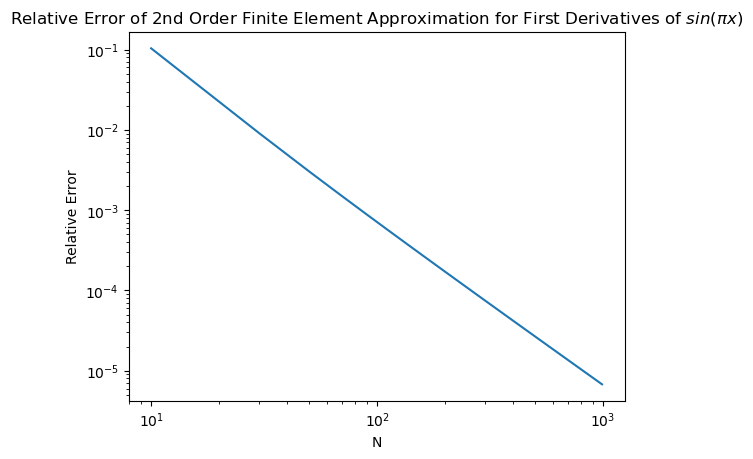

In [68]:
Ns = np.arange(10,1000,20)
r = np.zeros(len(Ns))
i=0
for N in Ns:   
    x = np.linspace(-1,1,N)
    r[i] = np.linalg.norm(np.pi*np.cos(np.pi*x) - np.matmul(D1(x),np.sin(np.pi*x))) / np.linalg.norm(np.pi*np.cos(np.pi*x))
    i+=1

plt.figure()
plt.loglog(Ns,r)
plt.xlabel('N')
plt.ylabel('Relative Error')
plt.title(r'Relative Error of 2nd Order Finite Element Approximation for First Derivatives of $sin(\pi x)$')

Expected rate of convergence is probably quadratic since the error scales by $\Delta x^2$. 

**(e)** [4] Suppose we knew the *first derivative* of a function $f(x)$ at a discrete set of points and wanted to solve for the discrete function itself.  i.e.  ideally given $D$ and vector $\mathbf{y} = f'(\mathbf{x})$,  we would like to be able to solve the linear algebra problem

$$
    D\mathbf{f} = \mathbf{y}
$$

for $\mathbf{f}\approx f(\bf{x})$.  Discuss any issues we might have with this approach.

We are not gaurenteed this system of equations has a solution. Yes, D is square, but it may not be invertible depending on its rank and therefore there would not be a solution. We could also have a scenario where D is rank-deficient and then we have an infinite number of solutions, which would make a non-unique $\textbf{f}$ which I don't think is realistic. We would have to know the structure of D to know this, although if D is diagonal or diagonally dominate, which seems likely given the previous parts of this homework, it would be invertible and thus this system of equations would have a solution for $\textbf{f}$.